In [1]:
import sys
sys.path.insert(0, '../../gofher')

import os
import matplotlib.image as mpimg

from gofher import run_gofher
from visualize import visualize
from file_helper import write_csv,check_if_folder_exists_and_create
from spin_parity import read_spin_parity_galaxies_label_from_csv, standardize_galaxy_name

In [2]:
survery_to_use = "panstarrs"

BANDS_IN_ORDER = ['g','r','i','z','y'] #Important: Must stay in order of BLUEST to REDDEST Waveband (Editting this will cause gofher to no longer correctly evaluate redder side of galaxy)
REF_BANDS_IN_ORDER = ['i','z','y','r','g'] #The prefernce each waveband being choosen as refernce band from highest priority to lowest priority

'''
survery_to_use = "sdss" #Note: for sdss we are not using u do to poor quality

BANDS_IN_ORDER = ['g','r','i','z'] #Important: Must stay in order of BLUEST to REDDEST Waveband (Editting this will cause gofher to no longer correctly evaluate redder side of galaxy)
REF_BANDS_IN_ORDER = ['r','i','z','g'] #The prefernce each waveband being choosen as refernce band from highest priority to lowest priority
'''

'\nsurvery_to_use = "sdss" #Note: for sdss we are not using u do to poor quality\n\nBANDS_IN_ORDER = [\'g\',\'r\',\'i\',\'z\'] #Important: Must stay in order of BLUEST to REDDEST Waveband (Editting this will cause gofher to no longer correctly evaluate redder side of galaxy)\nREF_BANDS_IN_ORDER = [\'r\',\'i\',\'z\',\'g\'] #The prefernce each waveband being choosen as refernce band from highest priority to lowest priority\n'

In [3]:
#panstarrs:
bin_size = None #None or a positive integer

In [4]:
generate_verbose_csv = True#True
generate_ebm_csv = False
generate_params_csv = False#True
generate_visualization = True
save_visualization = False

In [5]:
name = "NGC4527"
paper_label = "SW"
folder = "figure8"

#path_to_input = "..\\..\\..\\spin-parity-catalog-data\\panstarrs\\{}".format(folder)
#path_to_output = "..\\..\\..\\..\\"
path_to_input = "../../../spin-parity-catalog-data/panstarrs/{}".format(folder)
#path_to_output = "../../../../"
path_to_output = "/Users/cora-at-work/Desktop/test"

In [6]:
def get_fits_path(name,band):
    """the file path of where existing fits files can be found"""
    return os.path.join(path_to_input,name,"{}_{}.fits".format(name,band))

def get_color_image_path(name):
    return os.path.join(path_to_input,name,"{}_color.jfif".format(name))

findfont: Font family ['Nimbus Roman No9 L'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Nimbus Roman No9 L'] not found. Falling back to DejaVu Sans.


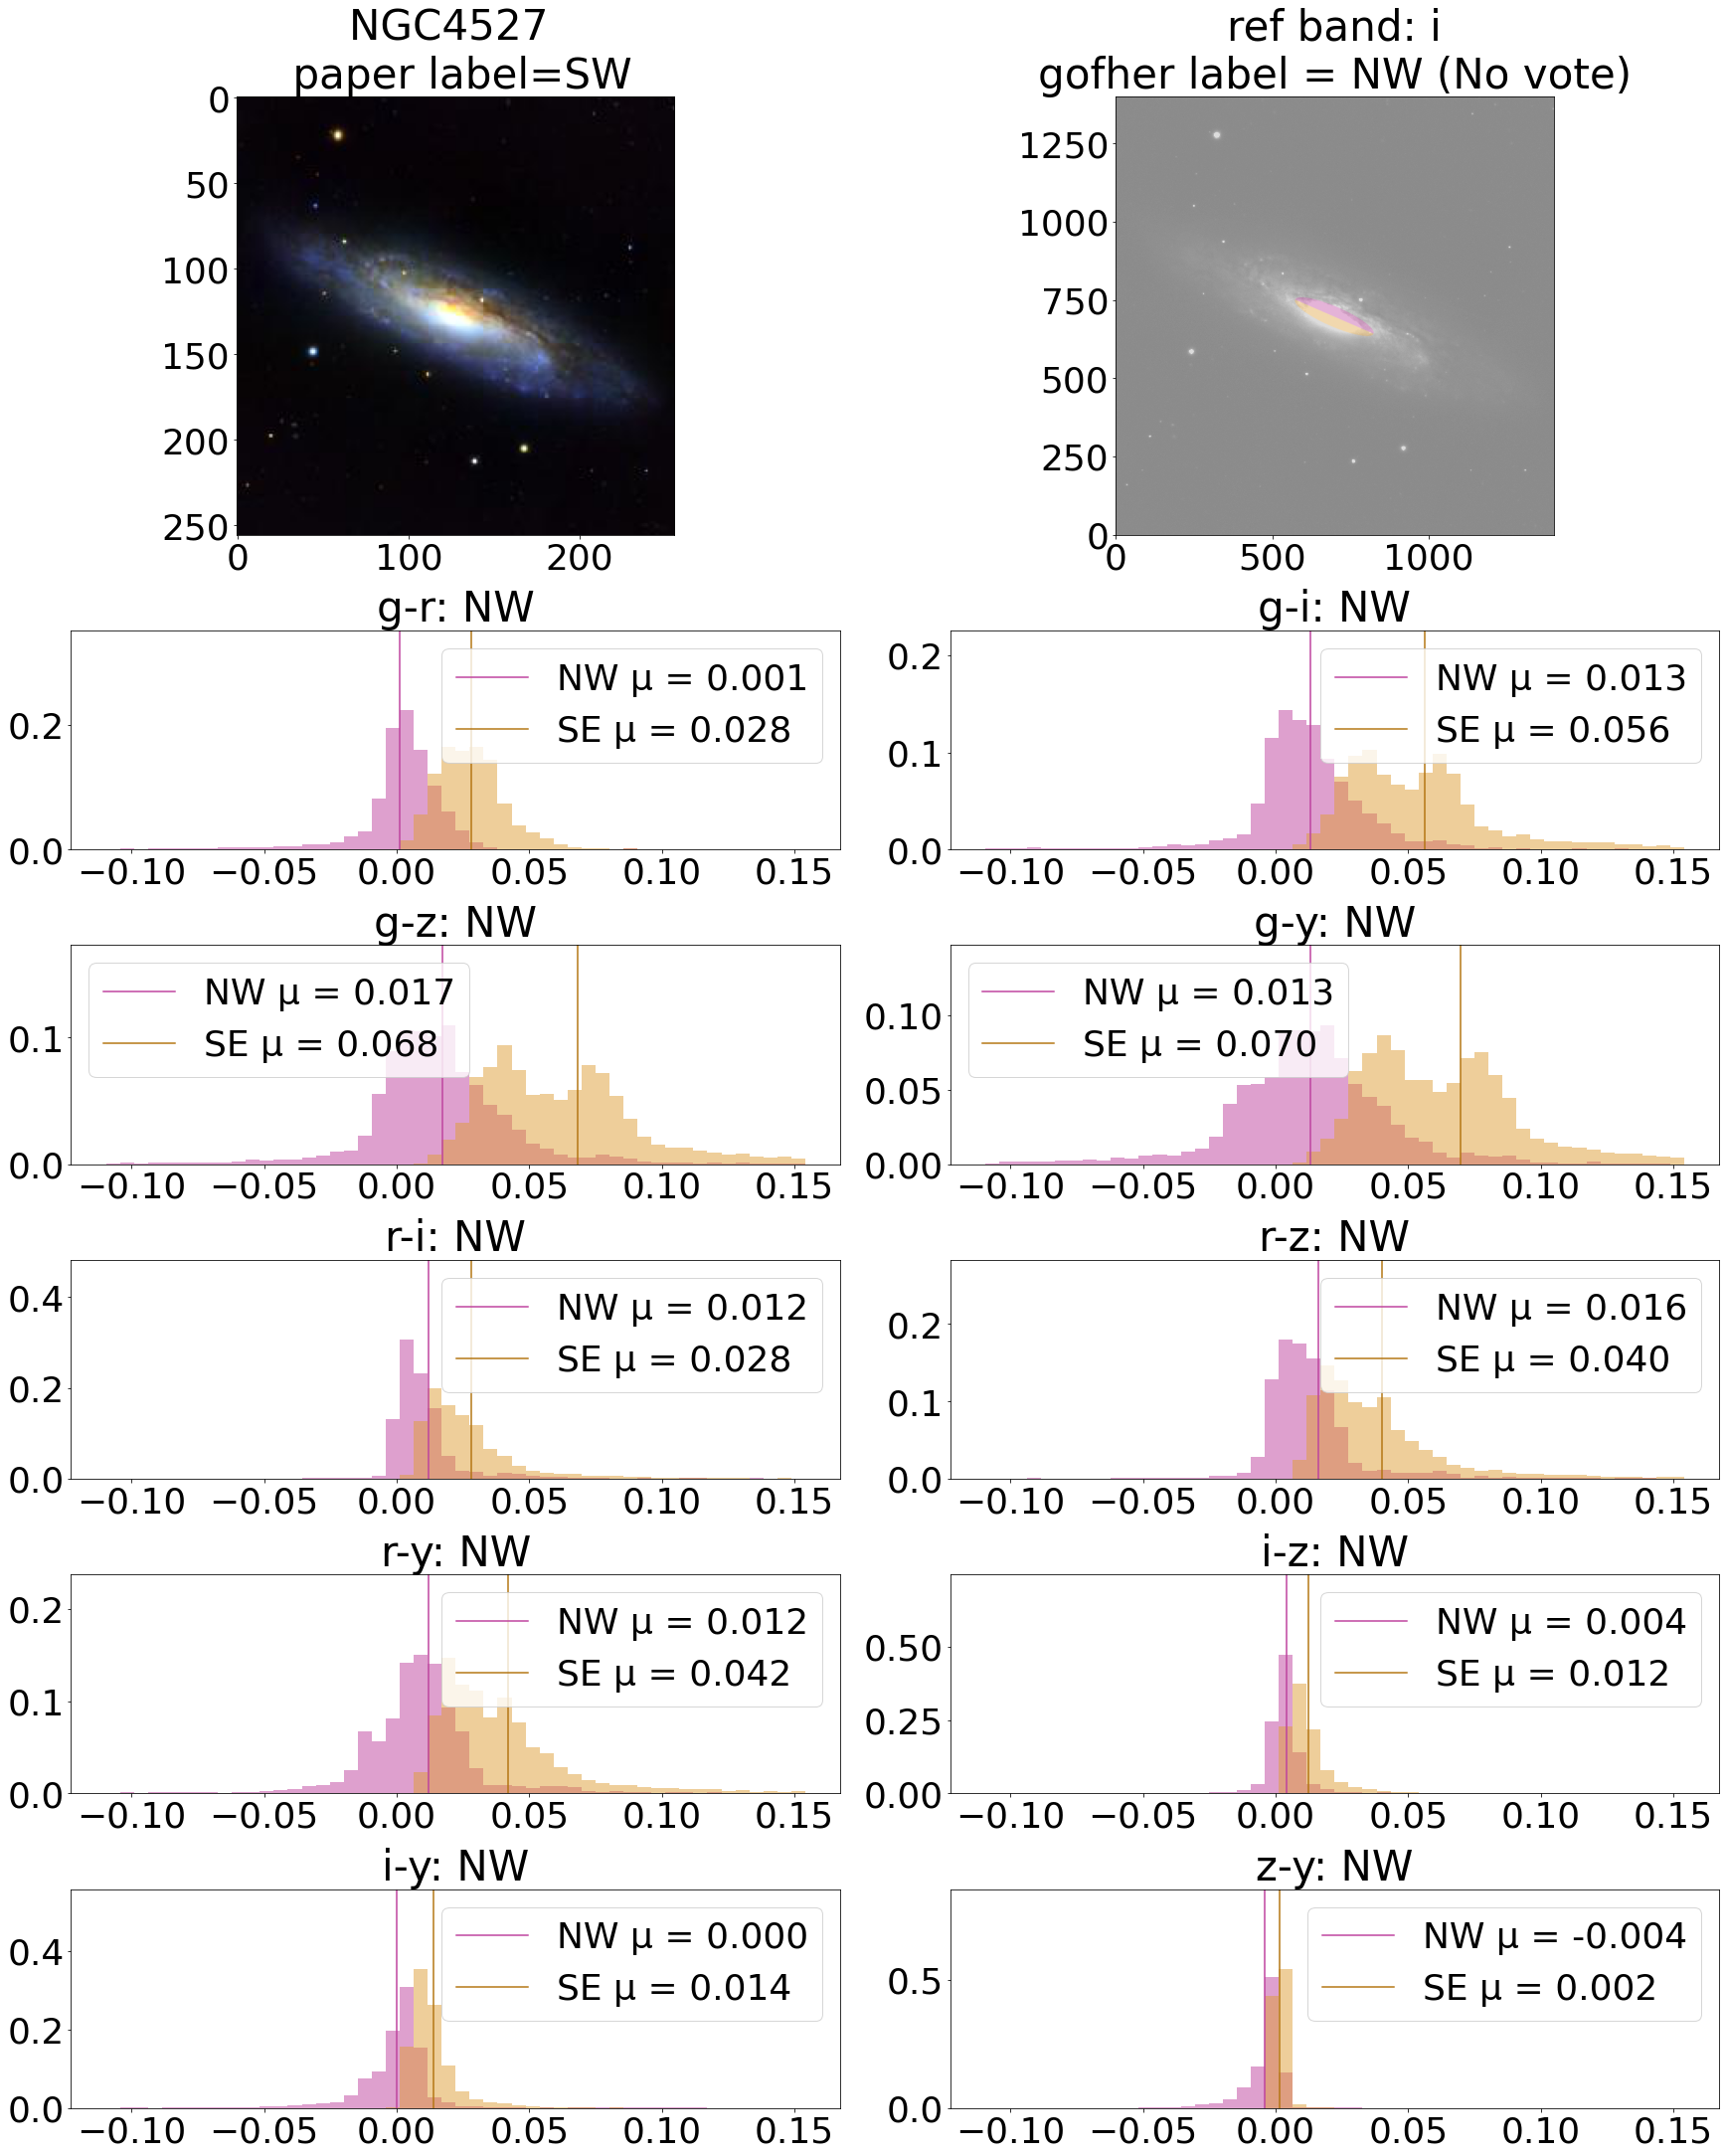

In [7]:
if not os.path.exists(path_to_input):
    raise ValueError("The path to the input is not found {} - make sure you update path_to_input".format(path_to_input))

if not os.path.exists(path_to_output):
    raise ValueError("The path output is not found {} - make sure you update ppath_to_output".format(path_to_output))

gal = run_gofher(name,get_fits_path,['g','r','i','z','y'],['i','z','y','r'], paper_label)
color_image = color = mpimg.imread(get_color_image_path(name))
visualize(gal,color_image,BANDS_IN_ORDER,paper_label,save_path='',color_flip=(survery_to_use=="sdss"),show_stats=False)

verbose_header = []
verbose_rows = []
(header,row) = gal.get_verbose_csv_header_and_row(BANDS_IN_ORDER,paper_label)
if len(verbose_header) == 0: verbose_header = header
verbose_rows.append(row)
verbose_csv_path = os.path.join(path_to_output,"{}_verbose.csv".format(folder))
write_csv(verbose_csv_path,verbose_header,verbose_rows)

In [9]:
for bp in gal.band_pairs:
    band_pair = gal.band_pairs[bp]
    print(band_pair.wasserstein_distance)
    print(band_pair.laplace_smoothed_kld)

0.025905329873669048
2.734195689398819
0.0409050020736601
2.894775470321365
0.04586649521000435
2.783601604601006
0.05020119810971394
2.741156381324603
0.01658388296636105
1.9294574150573125
0.02483441302747143
2.459984889766602
0.029935489041513014
2.451240464624474
0.008577837179835974
1.7573631435661587
0.014466023966525446
2.302606855459027
0.006006400327449225
1.6791630489519576


In [10]:
band_pair = gal.band_pairs["g-r"]

In [19]:
import matplotlib.pyplot as plt
from scipy.stats import gamma
import numpy as np

In [49]:
pos_dist = (band_pair.pos_side-np.min(band_pair.pos_side))/(np.max(band_pair.pos_side)-np.min(band_pair.pos_side))
neg_dist = (band_pair.neg_side-np.min(band_pair.neg_side))/(np.max(band_pair.neg_side)-np.min(band_pair.neg_side))


pos_shape_est, pos_loc_est, pos_scale_est = gamma.fit(pos_dist)
neg_shape_est, neg_loc_est, neg_scale_est = gamma.fit(neg_dist)
x = np.linspace(0, 1, 100)

# Calculate the PDF of the fitted Gamma distribution
pos_pdf_fitted = gamma.pdf(x, pos_shape_est, loc=pos_loc_est, scale=pos_scale_est)
neg_pdf_fitted = gamma.pdf(x, neg_shape_est, loc=neg_loc_est, scale=neg_scale_est)

(array([0.46781053, 2.62648482, 3.27467371, 2.48130224, 0.74791025,
        0.27863323, 0.06892506, 0.02932981, 0.0161314 , 0.00879894]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

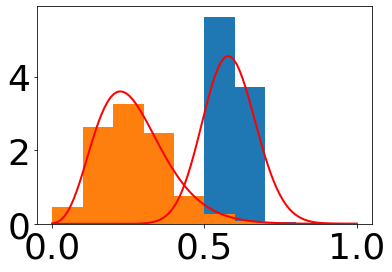

In [50]:
plt.plot(x, pos_pdf_fitted, 'r-', lw=2, label='Fitted Gamma PDF')
plt.plot(x, neg_pdf_fitted, 'r-', lw=2, label='Fitted Gamma PDF')
plt.hist(pos_dist,density=True)
plt.hist(neg_dist,density=True)
#plt.hist(band_pair.neg_side)

In [70]:
from scipy.stats import ks_1samp,kstest,ks_2samp

#y = gamma.rvs(pos_shape_est, pos_loc_est, pos_scale_est)
#y = np.random.gamma(pos_shape_est, pos_scale_est, 1000)
#ks_1samp(y,lambda x: gamma.cdf(x,pos_shape_est, pos_loc_est, pos_scale_est))
#kstest(pos_dist, gamma.cdf, args=(neg_shape_est, neg_loc_est, neg_scale_est))
#kstest(pos_dist,neg_dist)
ks_2samp(pos_dist,neg_dist)

KstestResult(statistic=0.9066928835773833, pvalue=1.0)

In [78]:
for bp in gal.band_pairs:
    band_pair = gal.band_pairs[bp]
    print(ks_2samp(band_pair.pos_side,band_pair.neg_side))

KstestResult(statistic=0.7188997549234508, pvalue=1.0)
KstestResult(statistic=0.6914390388601954, pvalue=1.0)
KstestResult(statistic=0.6771932031105098, pvalue=1.0)
KstestResult(statistic=0.6839470233144471, pvalue=1.0)
KstestResult(statistic=0.5612689866316912, pvalue=1.0)
KstestResult(statistic=0.5790210565594079, pvalue=1.0)
KstestResult(statistic=0.6205474930132931, pvalue=1.0)
KstestResult(statistic=0.563049974361163, pvalue=1.0)
KstestResult(statistic=0.6239236498547089, pvalue=1.0)
KstestResult(statistic=0.5263827571686408, pvalue=1.0)
